In [1]:
include("./lotka.jl")
include("./dynopt_rk.jl")
include("./dynopt_sensitivity.jl")
include("./dynopt_newton.jl")

using LinearAlgebra
using Printf
using .lotka
using .dynopt_rk
using .dynopt_sensitivity
using .dynopt_newton
import .dynopt_newton:newton_eval_funder, newton_eval_fun, newton_solve 

The following function implements the single shooting method for solving the nonlinear two-point boundary value problem
\begin{align*}
 & \dot{x}(t) = f(t,x(t),p)\ t\in[t_0,t_{\text f}] \\
\text{s.t.}\ & r(x(t_0),x(t_{\text f}),p)=0
\end{align*}
Both $s_0=x(t_0)$ and $p$ are considered degrees of freedom.

This is the concrete type of a root finding problem function $F(x)=r(s_0,x(t_f;t_0,s_0,p))$ in $x=(p,s_0)$ which is evaluated using the single shooting methods for BVPs.

In [2]:
mutable struct SiShFunction <: NewtonFunction
    bvp   :: BVPStruct
    t0    :: Float64           # start time
    tf    :: Float64           # end time
    h     :: Float64           # RK4 step size
end


single_shooting (generic function with 4 methods)

This function computes the value of a `SiShFunction` in `xk`$=(p^{(k)},s_0^{(k)})$.

In [ ]:

function newton_eval_fun(
    F :: SiShFunction,
    xk :: Vector{Float64}
) :: Vector{Float64}
    nx, np = F.bvp.ivp.nx, F.bvp.ivp.np
    # the iterate x^k = (s0^k p^k)
    s0k = xk[1:nx]
    pk = xk[nx+1:nx+np]
    # solve the IVP
    eta_end, _, _ = rungeKutta( (t,x) -> F.bvp.ivp.f(t,x,pk), s0k, F.t0, F.tf, F.h, RK4)
    # extract x(tf;t0,s0^k,pl) 
    x_end = eta_end[1:nx]
    # evaluate r^k = r(s0^k,x(tf;t0,s0^k,p^k),p^k)
    rk = F.bvp.r(s0k,x_end,pk)
    # return F(xk)
    return rk
end


This functions computes the value and the total derivative of a `SiShFunction` in `xk`$=(p^{(k)},s_0^{(k)})$.
The state and parameter sensitivities are computed using the variational IVP.

In [ ]:

function newton_eval_funder(
    F :: SiShFunction,
    xk :: Vector{Float64}
) :: Tuple{Vector{Float64}, Matrix{Float64}}
    nx, np = F.bvp.ivp.nx, F.bvp.ivp.np
    # the iterate x^k = (s0^k p^k)
    s0k = xk[1:nx]
    pk = xk[nx+1:nx+np]
    # solve the IVP and the variational IVP using augmented initial value and right hand side
    s0k_aug = augmentBothVariationIv(s0k, np)        
    eta_end, _, _ = rungeKutta(
        (t,x) -> augmentBothVariationRhs(
            x -> F.bvp.ivp.f(t,x,pk), 
            x -> F.bvp.ivp.dfdx(t,x,pk), 
            x -> F.bvp.ivp.dfdp(t,x,pk),
            x, nx, np),                
        s0k_aug, F.t0, F.tf, F.h, RK4)

    # extract x(tf;t0,s0^k,pl) and the sensitivty W(tf;t0,s0^k,p^k)
    x_end = eta_end[1:nx]
    W_end = reshape(eta_end[nx+1:end],(nx,nx+np))
    # compute derivative dr(s0^k,x(tf;t0,s0^k,p^k),p^k) / d (s0,p)
    #                  = dr/d(s0,p) + dr/ds_end * dx(tf;t0,s0^k,p^k)/d(s0,p)
    Dk = hcat(F.bvp.drdx0(s0k,x_end,pk), F.bvp.drdp(s0k,x_end,pk)) + F.bvp.drdx1(s0k,x_end,pk) * W_end 
    # evaluate r^k = r(s0^k,x(tf;t0,s0^k,p^k),p^k)
    rk = F.bvp.r(s0k,x_end,pk)
    # return F(xk) 
    return rk, Dk
end


This function solves the linear system in Newton's method for a single shooting system matrix and vector.
No structures exist that we could exploit, so we use a dense LU decomposition, `\` in julia.

In [ ]:

function newton_solve(
    F :: SiShFunction,
    D :: Matrix{Float64},          # dF(x^k)/dx
    v :: Vector{Float64}    # F(x^k)
) :: Vector{Float64}
    return D \ v
end


This is the single shooting method. It is just Newton's method `newton`, applied to the single shooting function
`SiShFunction`.

In [ ]:

# single shooting is just newton's method applied to the boundary condition
function single_shooting(
    bvp :: BVPStruct,
    t0 :: Float64, tf :: Float64,                                         # time horizon
    s0 :: Vector{Float64}, p0 :: Vector{Float64},                         # initial guesses
    itmax :: Int64 = 100, tol :: Float64 = 1.0e-8, h :: Float64 = 1.0e-3  # numerics
)
    nx, np = bvp.ivp.nx, bvp.ivp.np

    F = SiShFunction(bvp, t0, tf, h)

    x_opt = newton(F, vcat(s0,p0), itmax, tol)
    return x_opt[1:nx], x_opt[nx+1:nx+np]
end

We solve variants of the Lotka-Volterra BVP.

In [9]:
lotkabvp = LotkaBVP()
s0_opt, p_opt = single_shooting(lotkabvp, 0.0, 10.0, [1.5, 0.5], [1.0, 1.0], 1000)

iter    ||resid||      ||step||          size  type
  1    1.8429e+00    1.3739e+00    5.0000e-01  N
  2    1.1467e+00    1.0652e+01    1.0000e+00  N
Function evaluation failed.


([1.0, 1.0], [8.153635853341472, -6.113794952827794])

We use the trajectory variant of the Runge-Kutta method to plot the solution. Check that the boundary conditions are indeed met.

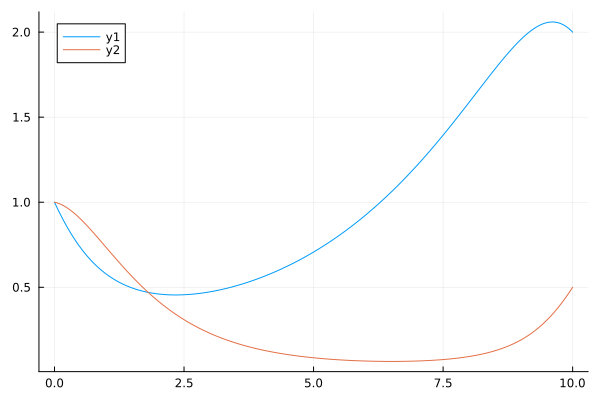

In [4]:
t_traj, x_traj = rungeKuttaTraj((t,x) -> lotkabvp.ivp.f(t,x,p_opt), s0_opt, 0.0, 10.0, 1.0e-3, RK4)
using Plots
plot(t_traj, x_traj[1,:])
plot!(t_traj, x_traj[2,:])